# Compute polarization angle

In [1]:
# Import packages

import os
import numpy as np
import pandas as pd
import tifffile
import matplotlib.pyplot as plt
from skimage import measure
from skimage.measure import regionprops
from scipy.ndimage import map_coordinates
from scipy.spatial.distance import pdist
from pathlib import Path

In [2]:
# USER INPUT

INPUT_FOLDER = r"/Users/laureleblanc/Desktop/Collective-twitching-2026/4_polarization_analysis/dataset"
RESULTS_FOLDER = r"/Users/laureleblanc/Desktop/Collective-twitching-2026/4_polarization_analysis/results"
OUTPUT_FOLDER = r"/Users/laureleblanc/Desktop/Collective-twitching-2026/4_polarization_analysis/figures"

SHOW_PLOTS = True
os.makedirs(RESULTS_FOLDER, exist_ok=True)
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

Found 3 WT files and 3 pilH files.


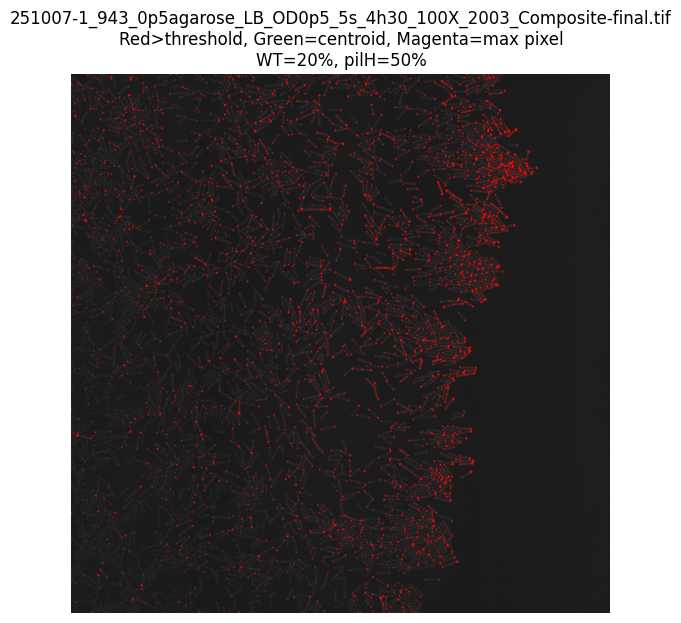

/var/folders/6n/9gbq90b95yggb0kc46nkmg8c0000gn/T/ipykernel_67128/2242894273.py:206: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_WT = pd.concat([df_WT,pd.DataFrame(rows)],ignore_index=True)


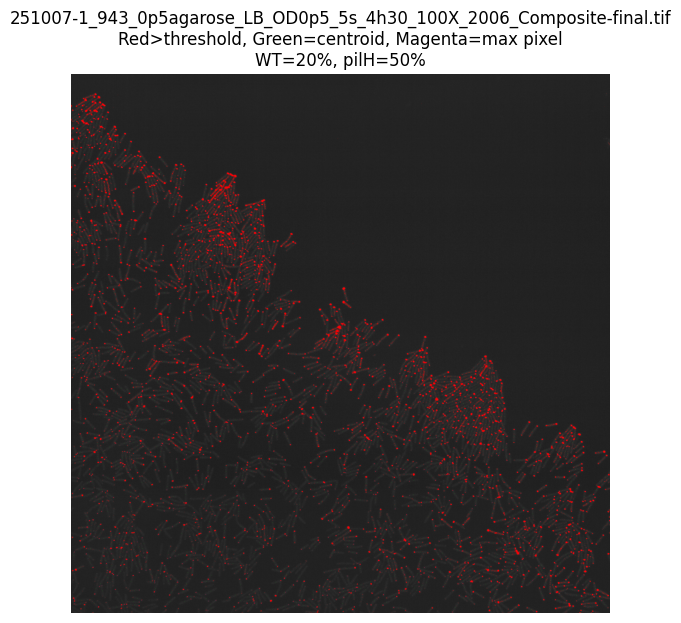

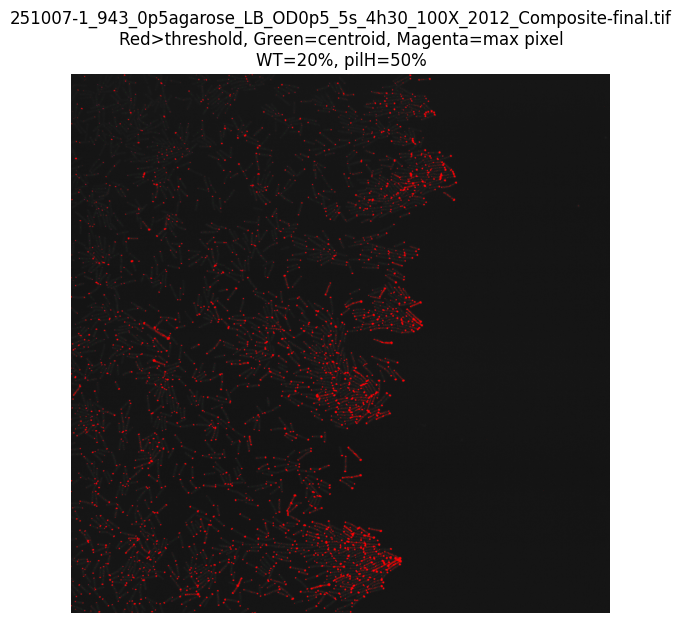

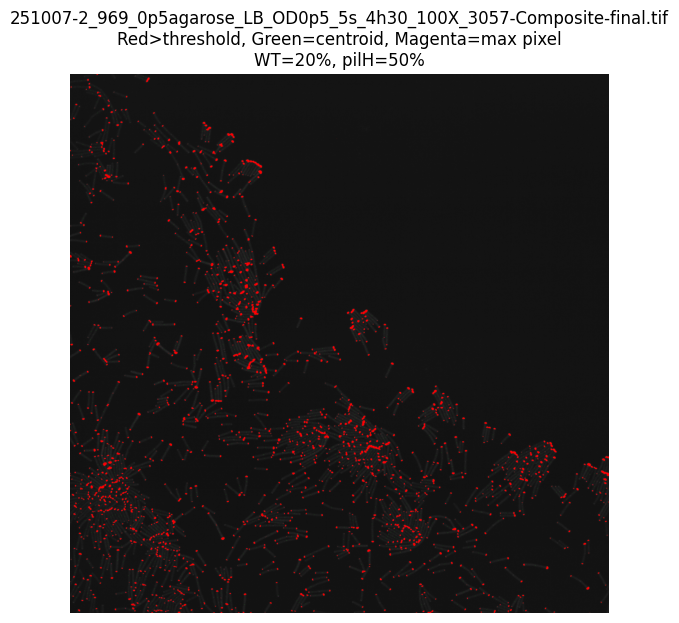

/var/folders/6n/9gbq90b95yggb0kc46nkmg8c0000gn/T/ipykernel_67128/2242894273.py:208: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_pilH = pd.concat([df_pilH,pd.DataFrame(rows)],ignore_index=True)


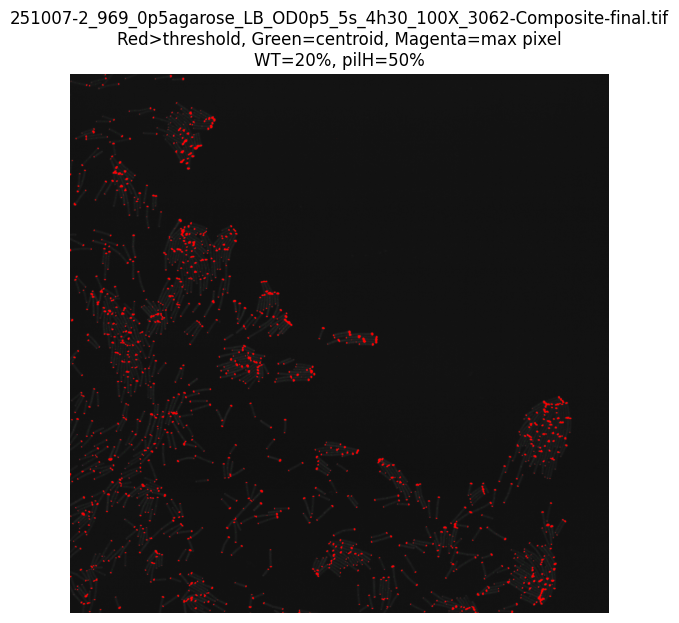

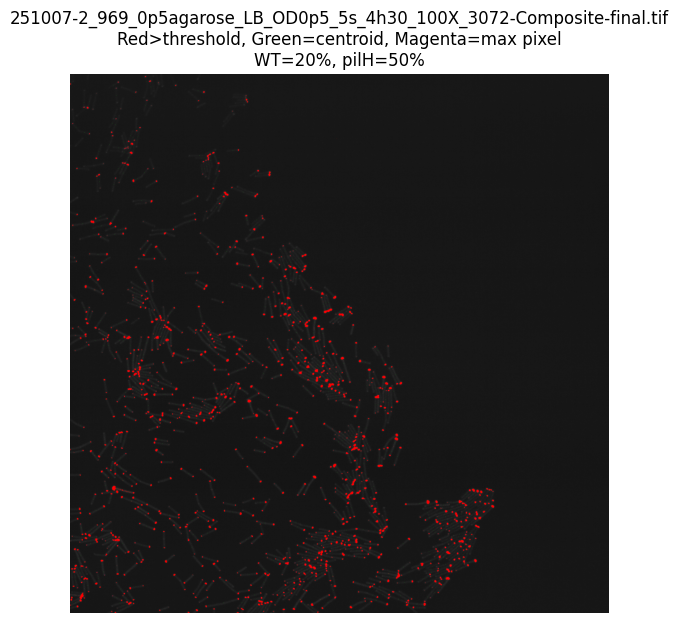


✅ Processing complete!
WT rows kept: 6514
pilH rows kept: 2583


In [6]:
# ---------------------------
# Helper functions
# ---------------------------
def load_tif_as_channels(path):
    arr = tifffile.imread(path)
    arr = np.asarray(arr)
    if arr.ndim == 3:
        if arr.shape[0] == 3:
            ch0, ch1, ch2 = arr[0], arr[1], arr[2]
        elif arr.shape[2] == 3:
            ch0, ch1, ch2 = arr[...,0], arr[...,1], arr[...,2]
        else:
            raise ValueError(f"Unexpected shape {arr.shape}")
    else:
        raise ValueError(f"Unsupported tif shape: {arr.shape}")
    return ch0.astype(float), ch1.astype(float), ch2.astype(float)

def extract_regions_from_mask(mask_2d):
    return regionprops(mask_2d.astype(np.int32))


def get_single_max_pixel_8connected(region, fluo_raw, max_dist_threshold=10):
    """
    Determine a single "max pixel" per bacterium using 8-connected neighborhood.
    If multiple pixels tie for max average:
        - If distance between any > max_dist_threshold, discard the bacterium (return None)
        - Else, take the centroid of max pixels
    Returns (y_max, x_max, max_avg_intensity) or (None, None, None) if discarded
    """
    mask = np.zeros_like(fluo_raw, dtype=bool)
    coords = region.coords
    mask[coords[:,0], coords[:,1]] = True

    ys, xs = coords[:,0], coords[:,1]
    max_avg = -np.inf
    max_pixels = []

    # Compute 8-connected averages
    for y, x in zip(ys, xs):
        neighbors = [
            (y-1, x-1), (y-1, x), (y-1, x+1),
            (y, x-1),   (y, x),   (y, x+1),
            (y+1, x-1), (y+1, x), (y+1, x+1)
        ]
        vals = [fluo_raw[ny, nx] for ny, nx in neighbors
                if 0 <= ny < fluo_raw.shape[0] and 0 <= nx < fluo_raw.shape[1] and mask[ny, nx]]
        if vals:
            avg_val = np.mean(vals)
            if avg_val > max_avg:
                max_avg = avg_val
                max_pixels = [(y, x)]
            elif avg_val == max_avg:
                max_pixels.append((y, x))

    # Handle multiple max pixels
    if len(max_pixels) == 0:
        return None, None, None
    elif len(max_pixels) == 1:
        return max_pixels[0][0], max_pixels[0][1], max_avg
    else:
        # Compute pairwise distances
        max_pixels_array = np.array(max_pixels)
        dists = pdist(max_pixels_array)
        if len(dists) > 0 and np.any(dists > max_dist_threshold):
            # Discard bacterium
            return None, None, None
        else:
            # Use centroid of max pixels
            y_mean = int(round(np.mean(max_pixels_array[:,0])))
            x_mean = int(round(np.mean(max_pixels_array[:,1])))
            return y_mean, x_mean, max_avg



def estimate_intensity_threshold_from_mask(mask, raw_image, multiplier=1.2):
    labeled_pixels = mask > 0
    if np.any(labeled_pixels):
        mean_region_intensity = np.mean(raw_image[labeled_pixels])
        return mean_region_intensity * multiplier
    else:
        return 0.0

# ---------------------------
# Build files_dict
# ---------------------------
input_path = Path(INPUT_FOLDER)
tif_files = sorted([p for p in input_path.iterdir() if p.suffix.lower() in ('.tif', '.tiff')])

files_dict = {'WT': [], 'pilH': []}
for p in tif_files:
    name = p.name
    if '943' in name:
        files_dict['WT'].append(str(p))
    elif '969' in name:
        files_dict['pilH'].append(str(p))

print(f"Found {len(files_dict['WT'])} WT files and {len(files_dict['pilH'])} pilH files.")

# ---------------------------
# Angle reference dictionary
# ---------------------------
# Key: filename, Value: reference angle in degrees
angle_refs = {
    "251007-1_943_0p5agarose_LB_OD0p5_5s_4h30_100X_2003_Composite-final.tif": 0.0,
    "251007-1_943_0p5agarose_LB_OD0p5_5s_4h30_100X_2006_Composite-final.tif": 55.0,
    "251007-1_943_0p5agarose_LB_OD0p5_5s_4h30_100X_2012_Composite-final.tif": 0.0,
    "251007-2_969_0p5agarose_LB_OD0p5_5s_4h30_100X_3057-Composite-final.tif": 50.0,
    "251007-2_969_0p5agarose_LB_OD0p5_5s_4h30_100X_3062-Composite-final.tif": 44.0,
    "251007-2_969_0p5agarose_LB_OD0p5_5s_4h30_100X_3072-Composite-final.tif": 36.0,
}

# ---------------------------
# Prepare dataframes
# ---------------------------
columns = ['bacterium_id', 'angle', 'max_intensity', 'region', 'filename', 'threshold_used']
df_WT = pd.DataFrame(columns=columns)
df_pilH = pd.DataFrame(columns=columns)

# ---------------------------
# Updated process_file() function
# ---------------------------
def process_file(path_str, strain, results_folder, show_plots=True):
    filename_short = Path(path_str).name
    ch0, ch1, ch2 = load_tif_as_channels(path_str)
    edge_seg, core_seg, fluo_raw = ch0, ch1, ch2

    # Label masks
    edge_labels = measure.label(edge_seg > 0) if edge_seg.max() <=1 else edge_seg.astype(int)
    core_labels = measure.label(core_seg > 0) if core_seg.max() <=1 else core_seg.astype(int)

    # Threshold multipliers
    multiplier = 1.2 if strain=='WT' else 1.5
    thr_edge = estimate_intensity_threshold_from_mask(edge_labels, fluo_raw, multiplier)
    thr_core = estimate_intensity_threshold_from_mask(core_labels, fluo_raw, multiplier)

    rows = []
    centroids_kept = []
    max_points_kept = []

    for mask, region_name, thr in [(edge_labels,'edge',thr_edge),(core_labels,'core',thr_core)]:
        for region in extract_regions_from_mask(mask):
            y_max, x_max, max_intensity = get_single_max_pixel_8connected(region, fluo_raw)
            if y_max is None or max_intensity < thr:
                #print(f"Discarded region ID {region.label} ({region_name}) in {filename_short}: max < threshold")
                continue
            y0, x0 = region.centroid
            vector = np.array([x_max - x0, y_max - y0])
            angle = np.degrees(np.arctan2(-vector[1], vector[0])) % 360

            # Rescale angle using reference
            ref_angle = angle_refs.get(filename_short, 0.0)
            angle_rescaled = (angle - ref_angle) % 360

            rows.append({
                'bacterium_id': int(region.label),
                'angle': float(angle_rescaled),
                'max_intensity': float(max_intensity),
                'region': region_name,
                'filename': filename_short,
                'threshold_used': float(thr)
            })
            centroids_kept.append((int(round(y0)), int(round(x0))))
            max_points_kept.append((int(round(y_max)), int(round(x_max))))

    # -------------------------------
    # Create RGB overlay
    # -------------------------------
    fluo_norm = np.clip(fluo_raw / np.max(fluo_raw),0,1) if np.max(fluo_raw)>0 else fluo_raw
    rgb = np.stack([fluo_norm, fluo_norm, fluo_norm], axis=-1)

    global_threshold = max(thr_edge, thr_core)
    red_mask = fluo_raw > global_threshold
    rgb[red_mask] = [1.0,0.0,0.0]  # Red

    for (yy, xx) in centroids_kept:
        if 0<=yy<rgb.shape[0] and 0<=xx<rgb.shape[1]:
            rgb[yy, xx] = [0.0,1.0,0.0]  # Green

    for (yy, xx) in max_points_kept:
        if 0<=yy<rgb.shape[0] and 0<=xx<rgb.shape[1]:
            rgb[yy, xx] = [1.0,0.0,1.0]  # Magenta

    rgb_uint8 = (rgb*255).astype(np.uint8)
    save_path = Path(results_folder)/f"{filename_short}_diagnostic_overlay.tif"
    tifffile.imwrite(save_path, rgb_uint8)

    if show_plots:
        plt.figure(figsize=(7,7))
        plt.imshow(rgb)
        plt.title(f"{filename_short}\nRed>threshold, Green=centroid, Magenta=max pixel\nWT=20%, pilH=50%")
        plt.axis('off')
        plt.show()
    else:
        plt.close('all')

    return rows

# ---------------------------
# Main loop
# ---------------------------
for group_key in ('WT','pilH'):
    for fullpath in files_dict[group_key]:
        try:
            rows = process_file(fullpath, group_key, RESULTS_FOLDER, show_plots=SHOW_PLOTS)
            if group_key=='WT':
                df_WT = pd.concat([df_WT,pd.DataFrame(rows)],ignore_index=True)
            else:
                df_pilH = pd.concat([df_pilH,pd.DataFrame(rows)],ignore_index=True)
        except Exception as e:
            print(f"Error processing {fullpath}: {e}")

# Ensure numeric types
for df in (df_WT, df_pilH):
    if not df.empty:
        df['angle'] = pd.to_numeric(df['angle'],errors='coerce')
        df['max_intensity'] = pd.to_numeric(df['max_intensity'],errors='coerce')
        df['threshold_used'] = pd.to_numeric(df['threshold_used'],errors='coerce')

# Save CSVs
df_WT.to_csv(Path(RESULTS_FOLDER)/"df_WT_fluo_vectors.csv",index=False)
df_pilH.to_csv(Path(RESULTS_FOLDER)/"df_pilH_fluo_vectors.csv",index=False)

print("\n✅ Processing complete!")
print(f"WT rows kept: {len(df_WT)}")
print(f"pilH rows kept: {len(df_pilH)}")


# Check rotation angles

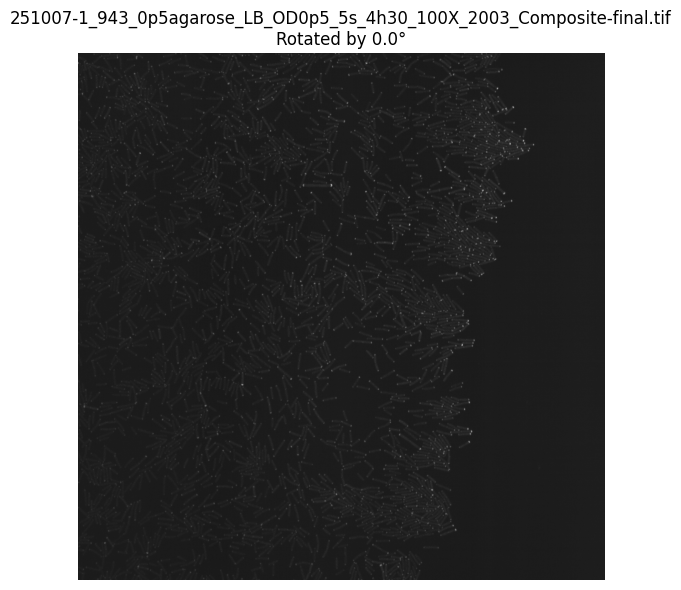

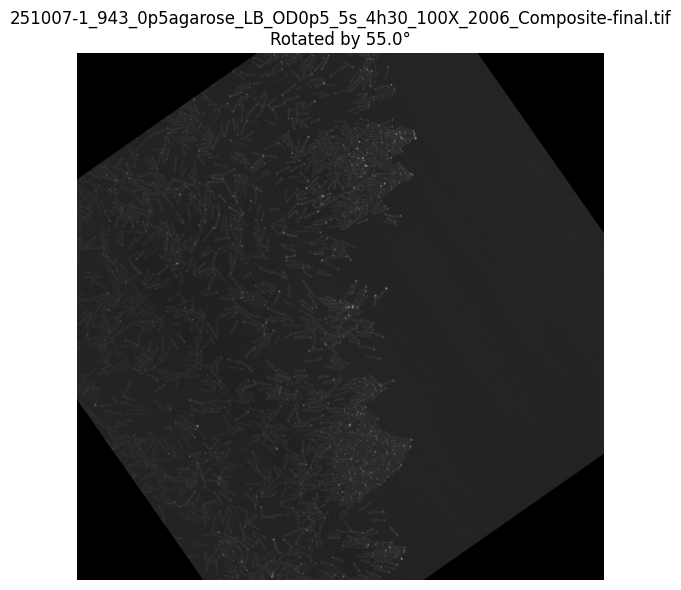

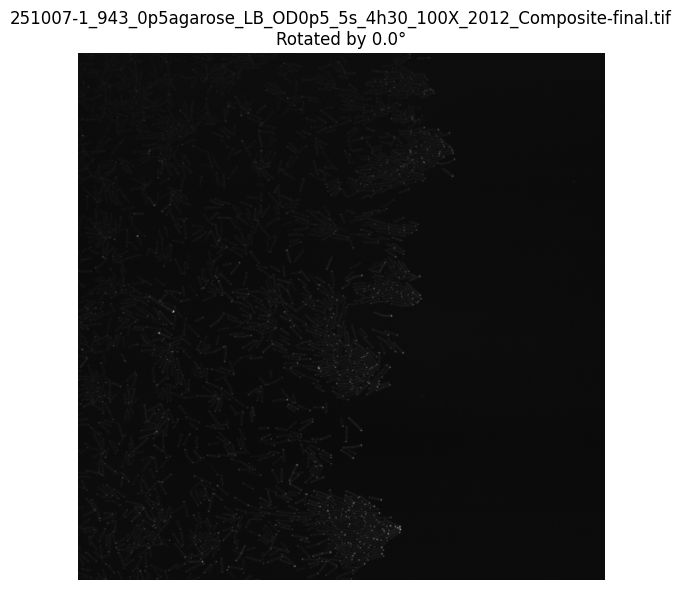

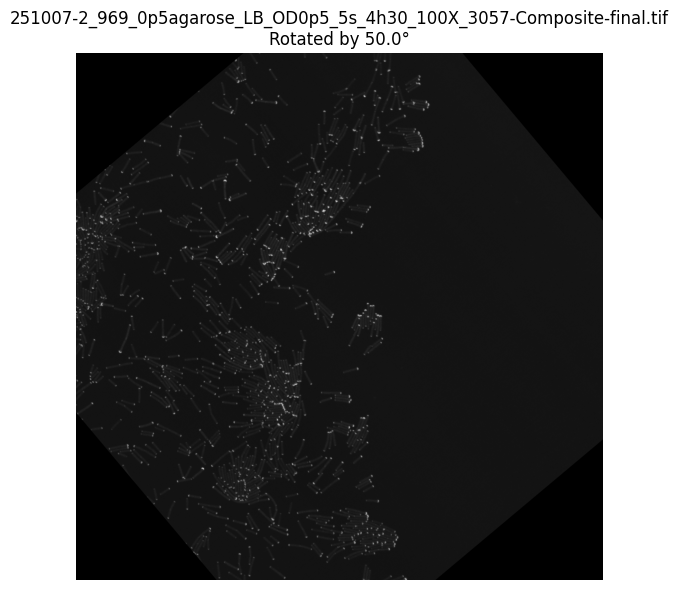

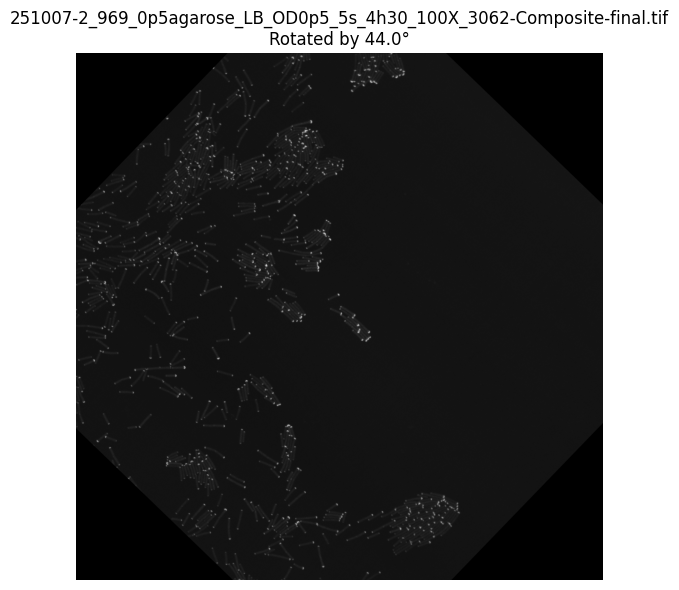

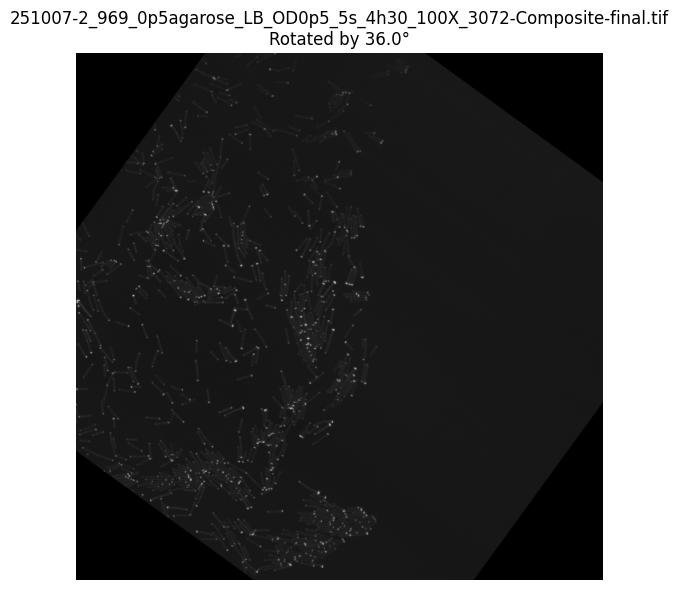

In [4]:
### Just to check the rotation
import tifffile
import numpy as np
import matplotlib.pyplot as plt
from skimage.transform import rotate
from pathlib import Path

angle_refs = {
    "251007-1_943_0p5agarose_LB_OD0p5_5s_4h30_100X_2003_Composite-final.tif": 0.0,
    "251007-1_943_0p5agarose_LB_OD0p5_5s_4h30_100X_2006_Composite-final.tif": 55.0,
    "251007-1_943_0p5agarose_LB_OD0p5_5s_4h30_100X_2012_Composite-final.tif": 0.0,
    "251007-2_969_0p5agarose_LB_OD0p5_5s_4h30_100X_3057-Composite-final.tif": 50.0,
    "251007-2_969_0p5agarose_LB_OD0p5_5s_4h30_100X_3062-Composite-final.tif": 44.0,
    "251007-2_969_0p5agarose_LB_OD0p5_5s_4h30_100X_3072-Composite-final.tif": 36.0,
}

# ---------------------------
# Helper function to load 3-channel TIFF
# ---------------------------
def load_third_channel(path):
    img = tifffile.imread(path)
    img = np.asarray(img)
    if img.ndim == 3:
        if img.shape[0] == 3:
            ch3 = img[2]
        elif img.shape[2] == 3:
            ch3 = img[...,2]
        else:
            raise ValueError(f"Unexpected image shape: {img.shape}")
    else:
        raise ValueError("Image does not have 3 channels")
    return ch3

# ---------------------------
# Batch process and plot
# ---------------------------
input_path = Path(INPUT_FOLDER)
tif_files = sorted([p for p in input_path.iterdir() if p.suffix.lower() in ('.tif','.tiff')])

for file_path in tif_files:
    filename_short = file_path.name
    ch3 = load_third_channel(file_path)
    
    # Get reference angle, default to 0 if not found
    ref_angle = angle_refs.get(filename_short, 0.0)
    
    # Rotate
    ch3_rot = rotate(ch3, -ref_angle, resize=False, preserve_range=True)
    
    # Plot
    plt.figure(figsize=(6,6))
    plt.imshow(ch3_rot, cmap='gray')
    plt.tight_layout()
    plt.title(f"{filename_short}\nRotated by {ref_angle}°")
    plt.axis('off')
    plt.show()


# Polar plots

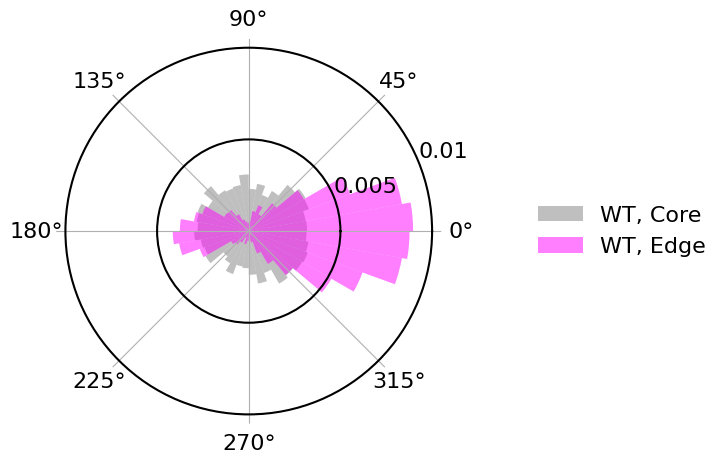

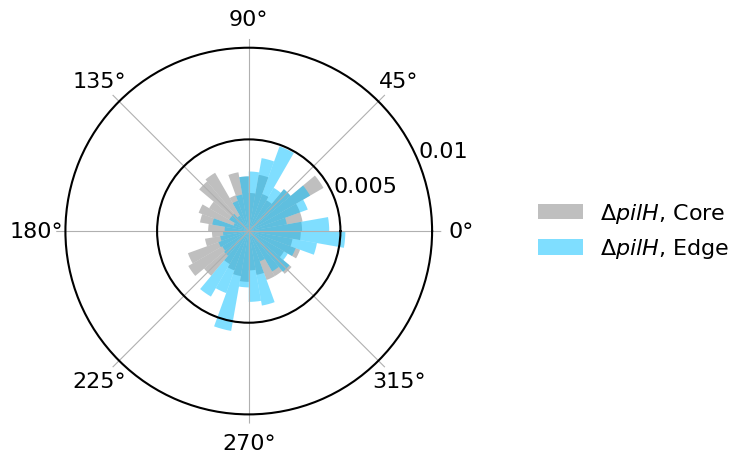

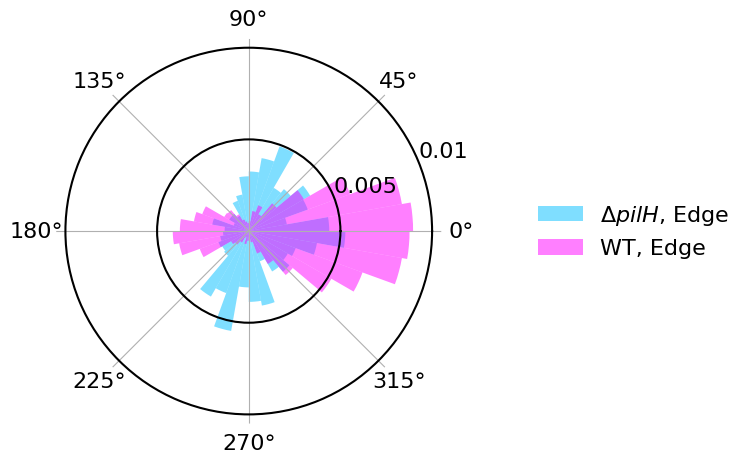

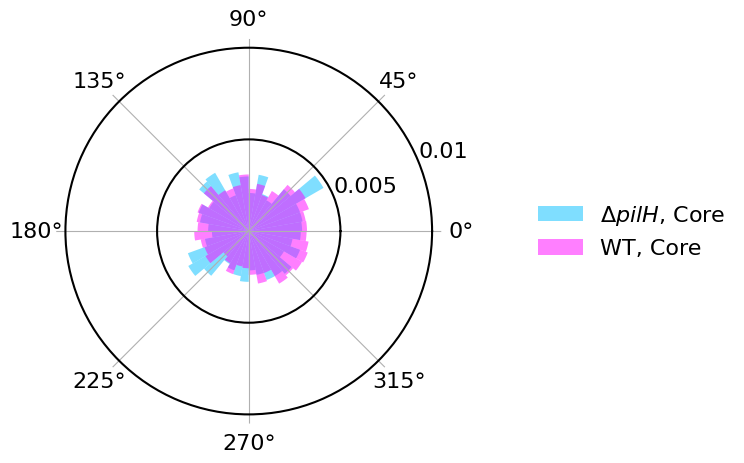

In [5]:
# ---------------------------
# Load CSVs
# ---------------------------
csv_WT = Path(RESULTS_FOLDER)/"df_WT_fluo_vectors.csv"
csv_pilH = Path(RESULTS_FOLDER)/"df_pilH_fluo_vectors.csv"
df_raw_WT = pd.read_csv(csv_WT)
df_raw_pilH = pd.read_csv(csv_pilH)

# ---------------------------
# Group by region
# ---------------------------
df_WT_edge = df_raw_WT[df_raw_WT['region']=='edge']
df_WT_core = df_raw_WT[df_raw_WT['region']=='core']

df_pilH_edge = df_raw_pilH[df_raw_pilH['region']=='edge']
df_pilH_core = df_raw_pilH[df_raw_pilH['region']=='core']

# ---------------------------
# Function to plot polar histogram
# ---------------------------
def plot_polar_hist(df1, df2, color1, color2, label1, label2, output_prefix, num_bins=36, font_size=16):
    """
    Plot a polar histogram comparing two angle distributions.

    Parameters:
    -----------
    df1, df2 : DataFrames with 'angle' column
    color1, color2 : str
        Colors for the two datasets
    label1, label2 : str
        Labels for legend
    output_prefix : Path
        Base path for saving
    num_bins : int, optional
        Number of bins (default 36)
    font_size : int, optional
        Base font size for labels, ticks, legend, and title
    """
    hist1, bin_edges = np.histogram(df1['angle'], bins=num_bins, range=(0,360), density=True)
    hist2, _ = np.histogram(df2['angle'], bins=num_bins, range=(0,360), density=True)
    bin_centers = np.deg2rad((bin_edges[:-1] + bin_edges[1:])/2)
    
    plt.figure(figsize=(5,5))
    ax = plt.subplot(111, polar=True)
    ax.bar(bin_centers, hist1, width=2*np.pi/num_bins, bottom=0.0, align='center', color=color1, alpha=0.5, label=label1)
    ax.bar(bin_centers, hist2, width=2*np.pi/num_bins, bottom=0.0, align='center', color=color2, alpha=0.5, label=label2)
    
    ax.spines['polar'].set_visible(False)
    ax.set_yticks([0.005, 0.01])
    ax.set_ylim(0, 0.0105)
    ax.yaxis.grid(True, color='black', linewidth=1.5)
    ax.yaxis.grid(True, which='minor', color='black', linewidth=1.5)
    ax.set_yticklabels([0.005, 0.01], fontsize=font_size)
    ax.tick_params(axis='x', labelsize=font_size)
    ax.legend(loc='center left', bbox_to_anchor=(1.2, 0.5), frameon=False, fontsize=font_size)

    #plt.tight_layout()
    plt.savefig(output_prefix.with_suffix(".png"), transparent=True, dpi=300, bbox_inches="tight")
    plt.savefig(output_prefix.with_suffix(".svg"), transparent=True, dpi=300, bbox_inches="tight")
    plt.show()


# ---------------------------
# Plot 4 figures
# ---------------------------

# Figure 1: WT core (gray) vs WT edge (magenta)
plot_polar_hist(df_WT_core, df_WT_edge,
                color1='gray', color2='magenta',
                label1='WT, Core', label2='WT, Edge',
                output_prefix=Path(OUTPUT_FOLDER)/"WT_core_vs_edge")

# Figure 2: pilH core (gray) vs pilH edge (deepskyblue)
plot_polar_hist(df_pilH_core, df_pilH_edge,
                color1='gray', color2='deepskyblue',
                label1=r'$\Delta\mathit{pilH}$, Core', label2=r'$\Delta\mathit{pilH}$, Edge',
                output_prefix=Path(OUTPUT_FOLDER)/"pilH_core_vs_edge")

# Figure 3: pilH edge (deepskyblue) vs WT edge (magenta)
plot_polar_hist(df_pilH_edge, df_WT_edge,
                color1='deepskyblue', color2='magenta',
                label1=r'$\Delta\mathit{pilH}$, Edge', label2='WT, Edge',
                output_prefix=Path(OUTPUT_FOLDER)/"pilH_edge_vs_WT_edge")

# Figure 4: pilH core (deepskyblue) vs WT core (magenta)
plot_polar_hist(df_pilH_core, df_WT_core,
                color1='deepskyblue', color2='magenta',
                label1=r'$\Delta\mathit{pilH}$, Core', label2='WT, Core',
                output_prefix=Path(OUTPUT_FOLDER)/"pilH_core_vs_WT_core")
